# tmrca.cu

**GPU-accelerated pairwise coalescence time estimation.**

Estimate the time to the most recent common ancestor (TMRCA) at every site for every pair of haplotypes — hundreds of times faster than existing CPU methods.

In [1]:
import numpy as np
import msprime
import time
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.ndimage import uniform_filter1d
from scipy.stats import pearsonr

import sys, os
sys.path.insert(0, 'python')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
from tmrca_cu import _core

rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.linewidth': 0.5,
})

MU, RHO, NE = 1.25e-8, 1e-8, 10_000
FF = '/sietch_colab/kkor/gamma_smc/resources/default_flow_field.txt'

## Simulate 200 haplotypes over 5 Mb

In [2]:
ts = msprime.sim_ancestry(
    samples=100, sequence_length=5_000_000,
    recombination_rate=RHO, population_size=NE, random_seed=42)
ts = msprime.sim_mutations(ts, rate=MU, random_seed=43)

G = ts.genotype_matrix().T.astype(np.uint8)
pos = np.array([v.position for v in ts.variants()], dtype=np.float64)
n, S = G.shape
n_pairs = n * (n - 1) // 2
all_pairs = [(i, j) for i in range(n) for j in range(i)]

print(f'{n} haplotypes  |  {S:,} segregating sites  |  {n_pairs:,} pairs')

200 haplotypes  |  15,064 segregating sites  |  19,900 pairs


## GPU inference — all 19,900 pairs in one shot

In [3]:
ctx = _core.FlowContext(G, pos, float(NE), MU, RHO, FF, 0)

# Warmup
ctx.run_fb_summary(all_pairs[:100])

# Timed: per-site TMRCA averaged across all pairs
t0 = time.perf_counter()
summary = ctx.run_fb_summary(all_pairs)
t_summary = time.perf_counter() - t0

# Timed: per-pair TMRCA traces for a few test pairs
test_pairs = [(0,1), (2,3), (10,15), (50,99)]
t0 = time.perf_counter()
traces = ctx.run_fb(test_pairs, mean_only=True)
t_traces = time.perf_counter() - t0

print(f'All {n_pairs:,} pairs (site summary): {t_summary:.3f}s  →  {n_pairs/t_summary:,.0f} pairs/s')
print(f'{len(test_pairs)} pairs (full traces):     {t_traces:.3f}s')

All 19,900 pairs (site summary): 0.064s  →  312,060 pairs/s
4 pairs (full traces):     0.020s


## Extract ground truth

In [4]:
def extract_truth(ts, i, j, positions):
    t = np.empty(len(positions))
    tree_iter = ts.trees(); tree = next(tree_iter)
    for idx, p in enumerate(positions):
        while p >= tree.interval.right: tree = next(tree_iter)
        t[idx] = tree.tmrca(i, j)
    return t

truths = {p: extract_truth(ts, *p, pos) for p in test_pairs}

for idx, p in enumerate(test_pairs):
    est = traces['mean'][:, idx]
    r = pearsonr(np.log(truths[p]), np.log(np.maximum(est, 1)))[0]
    print(f'  Pair {p}: r = {r:.3f}')

  Pair (0, 1): r = 0.823
  Pair (2, 3): r = 0.827
  Pair (10, 15): r = 0.872
  Pair (50, 99): r = 0.833


## The plot

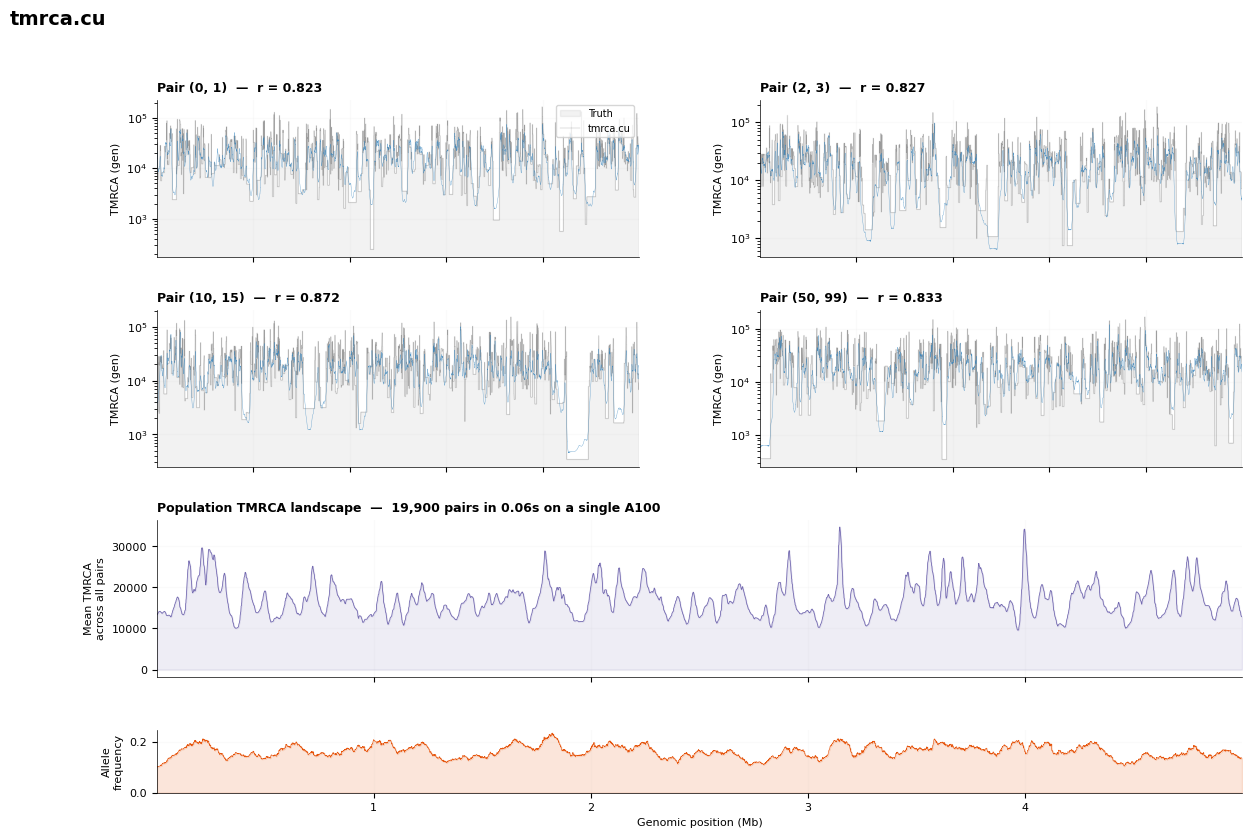

Saved demo_output.png


In [5]:
fig = plt.figure(figsize=(14, 9), facecolor='white')
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.25,
                       height_ratios=[2.5, 2.5, 2.5, 1])

x = pos / 1e6
C_TRUTH = '#252525'
C_EST = '#3182bd'
C_POP = '#756bb1'
C_DIV = '#e6550d'

# ── Top row: two single-pair traces ──────────────────────
for col, p in enumerate(test_pairs[:2]):
    ax = fig.add_subplot(gs[0, col])
    truth = truths[p]
    est = traces['mean'][:, test_pairs.index(p)]
    r = pearsonr(np.log(truth), np.log(np.maximum(est, 1)))[0]

    ax.fill_between(x, truth, alpha=0.06, color=C_TRUTH)
    ax.plot(x, truth, color=C_TRUTH, lw=0.25, alpha=0.4)
    ax.plot(x, est, color=C_EST, lw=0.25, alpha=0.8)
    ax.set_yscale('log')
    ax.set_ylabel('TMRCA (gen)')
    ax.set_xlim(x[0], x[-1])
    ax.set_title(f'Pair {p}  —  r = {r:.3f}', fontsize=9, loc='left', fontweight='bold')
    if col == 0:
        ax.legend(['Truth', 'tmrca.cu'], fontsize=7, loc='upper right')
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.05)

# ── Second row: two more pairs ────────────────────────────
for col, p in enumerate(test_pairs[2:4]):
    ax = fig.add_subplot(gs[1, col])
    truth = truths[p]
    est = traces['mean'][:, test_pairs.index(p)]
    r = pearsonr(np.log(truth), np.log(np.maximum(est, 1)))[0]

    ax.fill_between(x, truth, alpha=0.06, color=C_TRUTH)
    ax.plot(x, truth, color=C_TRUTH, lw=0.25, alpha=0.4)
    ax.plot(x, est, color=C_EST, lw=0.25, alpha=0.8)
    ax.set_yscale('log')
    ax.set_ylabel('TMRCA (gen)')
    ax.set_xlim(x[0], x[-1])
    ax.set_title(f'Pair {p}  —  r = {r:.3f}', fontsize=9, loc='left', fontweight='bold')
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.05)

# ── Third row: population TMRCA landscape ─────────────────
ax = fig.add_subplot(gs[2, :])
site_mean = summary['site_mean']
smooth = uniform_filter1d(site_mean.astype(np.float64), size=80)

ax.fill_between(x, smooth, alpha=0.12, color=C_POP)
ax.plot(x, smooth, color=C_POP, lw=0.6)
ax.set_ylabel('Mean TMRCA\nacross all pairs')
ax.set_xlim(x[0], x[-1])
ax.set_title(f'Population TMRCA landscape  —  {n_pairs:,} pairs in {t_summary:.2f}s on a single A100',
             fontsize=9, loc='left', fontweight='bold')
ax.tick_params(labelbottom=False)
ax.grid(True, alpha=0.05)

# ── Bottom row: diversity ─────────────────────────────────
ax = fig.add_subplot(gs[3, :])
het = G.mean(axis=0)
het_smooth = uniform_filter1d(het.astype(np.float64), size=300)
ax.fill_between(x, het_smooth, alpha=0.15, color=C_DIV)
ax.plot(x, het_smooth, color=C_DIV, lw=0.4)
ax.set_ylabel('Allele\nfrequency')
ax.set_xlabel('Genomic position (Mb)')
ax.set_xlim(x[0], x[-1])
ax.set_ylim(0, None)
ax.grid(True, alpha=0.05)

fig.suptitle('tmrca.cu', fontsize=14, fontweight='bold', y=0.98, x=0.02, ha='left')

fig.savefig('demo_output.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved demo_output.png')